# CNN

Stanford Notes: https://cs231n.github.io/convolutional-networks/

CNN = Convolutional Neural Network

- FNN do not scale well with image inputs
    - Say we have a 200x200x3 picture, then in the first layer a single neuron would have to have 120,000 weights. And we would want multiple such neurons. Clearly not optimal.
- If we were using regular FNNs for image recognition we would have to flatten the input into a vector. At that point we lose spatial information (which pixels are close to each other)
    - In CNN's we preserve this dimensionality by arranging the neurons in three dimensions (width, height, depth)
- CNNs can be built by using three types of layers: Convolutional Layer, Pooling Layer, and a Fully-Connected Layer

### Convolution Layer
- Each Conv Layer is a set of learnable filters that operate in 2D (widht,height) but are extended to full depth of the input volume.
    - So if the input is a colored image than the depth is 3 (RGB) and we have 3 of these 2D filters for every color channel
- As noted above, it is not practical to have fully connected layers when handling image input, so in Conv layers the neuron is only connected to a local region of the input
    - The size of that region is determined filter size
    - Think of the local region as a chunk of the image, e.g. top left corner
  
> The connections are local in 2D space (along width and height), but always full along the entire depth of the input volume.
- This means that we look at a chunk of the 2D space, but we always cover all the depth-channels. So if we have a colorful image of a cat, we might look at the left ear only but we do so in the red, green, and blue channels, not just one or two of them. (not the best explanation sry)
- The filters don't share weights, so if we have a 5x5x3 filter, that is kind of like 3 different 5x5 weight maps stacked on top of each other meaning that we have 75 (+1 for bias) weights total in the layer.
- The weight dimension is tied to the input in a pretty straightforward way (choose filter size then times it by depth). But the dimension of the output of the layer is dependent on depth, stride, and zero-padding.
    - Depth is a hyperparameter that we choose as part of the architecture. So this gets a bit confusing, at least for me it was. Depth of a filter is set in stone and is dependent on the depth of the input (RGB image -> filter has depth 3). The output depth is determined by us, by stacking multiple filters on top of each other
    - Stride is how many pixels the filter move at a time. So if stride is 1 then we move the filter to the next pixel, if stride is 2 then we move the filter 2 pixels over
    - Zero-padding is when we put zeros around the border of the input volume. This allows us to control exactly the spatial size (height,width) of the output
- To compute the spatial size of the output volume we can use the following formula $\frac{W-F+2P}{S} + 1$
    - W: spatial size of the input
    - F: filter size
    - P: amount of zero padding
    - S: stride parameter
- Filter sizes are usually squares with odd lengths (so there is a definitive center pixel when the filter is applied)
- Throughout the notes they refer to number of neurons as the number of pixels in the output of a layer. Which makes sense in some way, since a neuron in a MLP just produces a scalar, so if a layer outputs 100 scalars, that would mean that we had 100 neurons.
- They use an example architecture that won ImageNet challenge in 2012 to show that if you have 227x227x3 images and apply a convolution with $F=11$, $S=4$, $P=0$, and output depth of $96$ you get an output with dimensions 55x55x96. If all of those 290,400 neurons had their own 11x11x3 weights then the total count of parameters for just the first layer would be over 100 million.
- To remedy this huge parameter count we use **parameter sharing**. We assume that if a feature is useful to calculate at $(x_1,y_1)$ it probably is also useful at $(x_2,y_2)$
- If we take a depth slice (a 2D slice of (width,height)) we don't need to have unique a unique filter for each pixel in it now, we can just have one filter that we share across the pixels
- So instead of having to have 55x55x96 different filters we can have just 96 different filters that we reuse for every $(x,y)$ in that depth slice.
- The set of weights are commonly referred to as filters or kernels
- They have a really good animation in their notes for how the operations work. Nothing too convoluted (bu dum tsss) but still good to see
- There in an efficient operation of this process that converts a convolution to a dot product between two matrices, called `im2col`. I will attempt to describe it:
    - We first flatten the weights of every filter. For example if we had a 5x5x3 filter than we would flatten it to 75. If we have 10 such filters we would create a matrix of shape 10x75
    - Now we calculate the spatial size of our output, let's just say we get a 25x25 sized depth slice. This means that we applied the filter once for each pixel in the 25x25 output, meaning that we applied the filter on 625 different 5x5x3 patches.
    - So now we take our input and reshape it so each column corresponds to the pixel in the patches. In our example we have 75 pixels per patch and we have 625 ones so we would have a data matrix with dimensions 75x625.
    - Now we can just perform a dot product between the weight matrix and the new data matrix. Continuing the example we would have 10x625 output matrix. Then we just reshape it into the volume that we expect.
    - This entire process is a trade-off, we sacrifice RAM space (since we have lots of duplicates in the modified data matrix) for computation speed.
- If you use `im2col` then there will be duplicate pixels in the data matrix you create. Each of these pixels have gradients that are used in backprop. If those pixels are copies then each copy gets their own gradient modification from the operation, but we want the original pixel to accumulate all of those gradients into it. So there is two ways to remedy this (from what I've gathered):
    - Either the duplicates of the pixels are actually references, so modifying any one of them modifies the original, hence the gradients accumulate naturally,
    - Or you write a `col2im` function that manually sums the gradients for you. 
- You can also use 1x1 convolutions, which does seem counter intuitive but they do have uses since they operate through all the channels and can be used to alter the depth of input and output
- There are also dilated convolutions, instead of contiguous filters we have one with spaces between each cell. You get to sample more spread out input for the same computational cost.


### Pooling Layer
- The role of a pooling layer is to reduce spatial size of the representation to reduce the number of parameters
- Operates independently on every depth slice
- Most commonly uses the MAX operation
- It is NOT common to use padding
- The two commonly seen pooling layers both have strides 2 with spatial size of either 3 or 2, with 2 being the more common one
- Depth is preserved
- In terms of backprop, the MAX operation just reroutes the gradient into one value in the filter, i.e. the max value keeps its gradient while the others get gradient set to 0
- It seems that the field is moving away from pooling layers

### Extra
- You can convert a conv layer into a fully connected one and vice versa
    - I didn't really dig into this, they say its useful somehow to go from FC to conv. Here is a notebook that they link: https://github.com/BVLC/caffe/blob/master/examples/net_surgery.ipynb
- Most commonly, CNNs follow this pattern: `INPUT -> [[CONV -> RELU]*N -> POOL?]*M -> [FC -> RELU]*K -> FC`
- Having a stack of smaller filters is better than having one spatially large one
- In practice, whatever works best for ImageNet is probably what you should use as the base for your model. 

### Code
I am going to implement a slightly modified LeNet5 model and see if I can train it on the MNIST dataset. 

I am going to reuse (and slightly update) my scalar autograd engine that I made. So really this entire network will be made from scratch. This will make for veryyyyyyy slow code, but a really good learning exercise. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [2]:
class Node:
    def __init__(self, val, parents=[], operation=""):
        self.val = val
        self.parents = parents
        self.gradient = 0.0
        self.operation = operation

    def __add__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val + other_node.val, parents=[self,other_node],operation="+")
        return new_node

    def __mul__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val * other_node.val, parents=[self,other_node],operation="*")
        return new_node

    def __truediv__(self,other_node):
        new_node = Node(self.val / other_node.val, parents=[self,other_node],operation="/")
        return new_node

    def exp(self):
        return Node(np.exp(self.val),parents=[self], operation="exp")

    def log(self):
        return Node(np.log(self.val + 1e-15),parents=[self], operation="log")

    def relu(self):
        return Node(max(0,self.val),parents=[self], operation="relu")

    def sigmoid(self):
        new_val = 1/(1+np.exp(-self.val))
        return Node(new_val,parents=[self], operation="sigmoid")

    def _backprop(self):
        if not self.parents:
            pass
        elif self.operation == "+":
            self.parents[0].gradient += self.gradient
            self.parents[1].gradient += self.gradient
        elif self.operation == "*":
            self.parents[0].gradient += self.gradient * self.parents[1].val
            self.parents[1].gradient += self.gradient * self.parents[0].val
        elif self.operation == "/":
            self.parents[0].gradient += self.gradient * (1/self.parents[1].val)
            self.parents[1].gradient += self.gradient * (-self.parents[0].val / (self.parents[1].val **2))
        elif self.operation == "relu":
            self.parents[0].gradient += 0 if self.val <= 0 else self.gradient
        elif self.operation == "sigmoid":
            sigmoid_dx = self.val * (1-self.val)
            self.parents[0].gradient += self.gradient * sigmoid_dx
        elif self.operation == "exp":
            self.parents[0].gradient += self.gradient * self.val
        elif self.operation == "log":
            if self.parents[0].val == 0:
                print("Adding epsilon to prevent division by 0")
                self.parents[0] += 1e-5
            self.parents[0].gradient += self.gradient / self.parents[0].val 
    
    # This code was AI generated, I didn't really feel like implementing a topological sort
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for p in v.parents:
                    build_topo(p)
                topo.append(v)
        build_topo(self)
    
        self.gradient = 1.0
        for node in reversed(topo):
            node._backprop() 
            


### LeNet5
https://en.wikipedia.org/wiki/LeNet

This was a historic achievement by LeCun and colleagues in 1998 because it was the first CNN to demonstrate that deep learning was useful (-according to Gemini).

I stuck with most of the architecture except that they used some weird layer at the end (RBF layer), which is not used in modern implementations, so I just did another fully connected layer + softmax.

I worked on this code with AI, mostly to debug but also when I got lazy with writing out the loss function or activation function. The debugging part of this project was probably the most educational.

Implementing the `im2col` method was definitely the highlight. Felt kind of cool to implement it in a way that seems so different from what the convolution operation actually stands for. And it was nice to see that the way I set up my autograd worked well with accumulating gradients even when we duplicated some nodes.

Besides the `ConvLayer`, everything else was pretty basic and easy to implement.

In [3]:
class ConvLayer:
    def __init__(self, kernel_size, input_depth, output_depth, padding=0, stride=1):
        self.F = kernel_size
        self.in_c = input_depth           # in_c = in channels
        self.out_c = output_depth
        self.P = padding
        self.S = stride

        # I had a feeling you can use NumPy's dtype to make all of this easier, could've used this in BatchNorm notebook *sigh
        self.biases = np.empty((self.out_c,1,1),dtype=object)
        for i in range(self.out_c):
            self.biases[i] = Node(0)
        self.weights = np.empty((self.out_c, self.in_c, self.F, self.F), dtype=object)
        for i in np.ndindex(self.weights.shape):
            self.weights[i] = Node(rng.normal() * np.sqrt(2.0 / (self.in_c * self.F**2)))
            
    def get_output_size(self, W_y, W_x):
        output_x = (W_x-self.F+2*self.P) // self.S + 1
        output_y = (W_y-self.F+2*self.P) // self.S + 1
        return (self.out_c, output_x, output_y)

    def _im2col(self, X):
        weight_matrix = self.weights.reshape(self.out_c,-1)
        chunk_size = weight_matrix.shape[1]
        z_dim, y_dim, x_dim = self.get_output_size(X.shape[1], X.shape[2])
        data_matrix = np.empty((chunk_size,x_dim * y_dim), dtype=object)

        if self.P > 0:
            X = np.pad(X, ((0,0), (self.P, self.P), (self.P, self.P)), 
                       constant_values=Node(0))

        col_idx = 0
        for y in range(y_dim):
            for x in range(x_dim):
                # to accomadate for stride lengths
                y_start = y * self.S
                x_start = x * self.S
                # we assign the chunk to be references to the original node, so the gradients will flow properly
                chunk = X[0:self.in_c, y_start:y_start+self.F, x_start:x_start+self.F] 
                data_matrix[:, col_idx] = chunk.reshape(-1)
                col_idx += 1

        mat_mult = np.dot(weight_matrix,data_matrix)
        return mat_mult.reshape((z_dim, y_dim, x_dim))
    
    def forward(self, X):
        return self._im2col(X) + self.biases

    def parameters(self):
        return list(self.weights.flatten()) + list(self.biases.flatten())


class AvgPoolLayer:
    def __init__(self, size, stride):
        self.size = size
        self.stride = stride

    def pool(self,X):
        in_c, in_h, in_w = X.shape
        out_h = (in_h - self.size) // self.stride + 1
        out_w = (in_w - self.size) // self.stride + 1
        
        pooled_X = np.empty((in_c,out_h,out_w), dtype=object)

        for z in range(in_c):
            for y in range(out_h):
                for x in range(out_w):
                    y_start = y * self.stride
                    x_start = x * self.stride
                    chunk = X[z, y_start:y_start+self.size, x_start:x_start+self.size].flatten()

                    # Apparently we cant use np.sum() because it would start with sum=0 and try to add my node object to it. I need it to start with Node(0)
                    chunk_sum = chunk[0]
                    for i in range(1,len(chunk)):
                        chunk_sum = chunk_sum + chunk[i]
                        
                    pooled_X[z,y,x] = chunk_sum * Node(1/(self.size**2))

        return pooled_X


class FullyConnectedLayer:
    def __init__(self, input_dim, output_dim):
        self.weights = np.empty((input_dim, output_dim), dtype=object)
        self.biases = np.empty((output_dim), dtype=object)

        for i in range(output_dim):
            self.biases[i] = Node(0)
            for j in range(input_dim):
                self.weights[j,i] = Node(rng.normal()* np.sqrt(2.0 / input_dim))

    def forward(self, X):
        return np.dot(X,self.weights) + self.biases

    def parameters(self):
        return list(self.weights.flatten()) + list(self.biases.flatten())


class LeNet5:
    def __init__(self):
        self.conv1 = ConvLayer(5,1,6,padding=2)
        self.pool1 = AvgPoolLayer(2,2)
        self.conv2 = ConvLayer(5,6,16)
        self.pool2 = AvgPoolLayer(2,2)
        self.conv3 = ConvLayer(5,16,120)
        self.FC1 = FullyConnectedLayer(120,84)
        self.FC2 = FullyConnectedLayer(84,10)

    def relu_map(self, x):
        v_relu = np.vectorize(lambda node: node.relu()) # totally written by me
        return v_relu(x)

    def softmax(self,x):
        max_val = max(node.val for node in x)
        exps = [(node + (-max_val)).exp() for node in x]
        denominator = Node(0)
        for i in range(len(x)):
            denominator = denominator + exps[i]
            
        output = np.empty((len(x)), dtype=object)
        for i in range(len(x)):
            output[i] = exps[i] / denominator
        return output

    def cross_entropy_loss(self, output, target_idx):
        prob_of_correct_class = output[target_idx]
        loss = prob_of_correct_class.log() * Node(-1)
        return loss

    def parameters(self):
        params = []
        for layer in [self.conv1, self.conv2, self.conv3, self.FC1, self.FC2]:
            params.extend(layer.parameters())
        return params

    def forward(self,x):
        x = self.conv1.forward(x)
        x = self.relu_map(x)
        x = self.pool1.pool(x)
        x = self.conv2.forward(x)
        x = self.relu_map(x)
        x = self.pool2.pool(x)
        x = self.conv3.forward(x)
        x = self.relu_map(x)
        x = x.flatten()
        x = self.FC1.forward(x)
        x = self.relu_map(x)
        x = self.FC2.forward(x)
        x = self.softmax(x)
        return x
        

### Training
I'm using the MNIST dataset as did the original research of LeNet5. Nothing out of the ordinary here, just need to handle the NumPy to my Node object conversion. The training here is incredibly slow since we do not get the benefit of pretty much any optimizations that modern libraries or even Python afford us. 

In [21]:
from torchvision import datasets

train_set = datasets.MNIST(root='data', train=True, download=True)
test_set = datasets.MNIST(root='data', train=False, download=True)

x_train = train_set.data.numpy() / 255.0
y_train = train_set.targets.numpy()

x_test = test_set.data.numpy() / 255.0
y_test = test_set.targets.numpy()

In [13]:
def to_node_array(numpy_img):
    node_array = np.empty(numpy_img.shape, dtype=object)
    for i in np.ndindex(numpy_img.shape):
        node_array[i] = Node(numpy_img[i])
    return node_array

def train(X, Y, model, epochs, learning_rate):
    loss_history = []
    params = model.parameters()
    newX = []
    for i in range(len(X)):
        x = X[i]
        x = x[np.newaxis, :, :]
        x = to_node_array(x)
        newX.append(x)

    for epoch_num in range(epochs):
        print(f"Epoch: {epoch_num + 1}")
        for i in range(len(newX)):
            x = newX[i]
            y = Y[i]
            prediction = model.forward(x)
            loss = model.cross_entropy_loss(prediction, y)
            print(f"{i}/{len(X)} || loss: {loss.val}")
            loss_history.append(loss.val)
            loss.backward()
    
            for param in params:
                param.val -= param.gradient * learning_rate
                param.gradient = 0

    return loss_history
        

In [17]:
model = LeNet5()
losses = train(x_train[0:100], y_train[0:100], model, 3, 0.01)

Epoch: 0
0/100 || loss: 2.834272781952627
1/100 || loss: 2.3580193034581187
2/100 || loss: 2.9314608560872624
3/100 || loss: 2.703923040653521
4/100 || loss: 2.059869992257935
5/100 || loss: 2.9797036449599132
6/100 || loss: 2.614077432343971
7/100 || loss: 2.018144890112279
8/100 || loss: 2.0304979540886
9/100 || loss: 2.896985657369413
10/100 || loss: 1.917406318085291
11/100 || loss: 2.6173896340057174
12/100 || loss: 1.8021776066584057
13/100 || loss: 2.5989768169843144
14/100 || loss: 1.8932144367346977
15/100 || loss: 2.7856413824870447
16/100 || loss: 2.456860476734058
17/100 || loss: 2.7137399963556574
18/100 || loss: 2.296661750926636
19/100 || loss: 1.8082584166729507
20/100 || loss: 2.8419844350046066
21/100 || loss: 2.711464561715635
22/100 || loss: 1.9351974357951727
23/100 || loss: 1.8919999815378237
24/100 || loss: 1.9566246882617435
25/100 || loss: 2.555556854794266
26/100 || loss: 2.479400678523149
27/100 || loss: 1.639566434671888
28/100 || loss: 2.2331405750233935
29

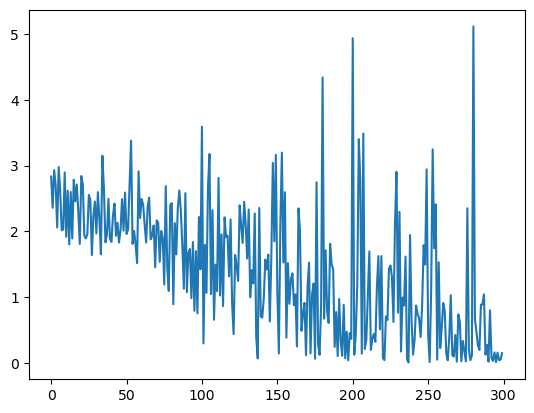

In [18]:
plt.plot(losses)

### Results
I did not train this model for long (15 minutes), but we can see that the model is clearly improving does better than just guessing on the test set. The goal of the notebook was not to have some incredible MNIST model so I wont really look to improve on this. This was pretty fun though.

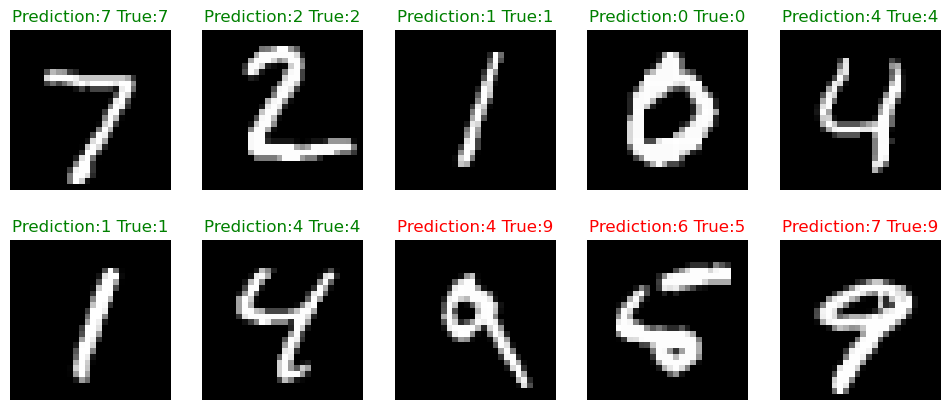

In [22]:
def visualize(model, X, Y, num=10):
    plt.figure(figsize=(12, 5))
    for i in range(num):
        x_node = to_node_array(X[i])
        x_node = x_node[np.newaxis,:,:]
        out = model.forward(x_node)
        probs = [n.val for n in out]
        pred, true = np.argmax(probs), Y[i]
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(X[i].squeeze(), cmap='gray')
        color = 'g' if pred == true else 'r'
        plt.title(f"Prediction:{pred} True:{true}", color=color)
        plt.axis('off')
    plt.show()

visualize(model,x_test,y_test)